## 初始化环境, 固定随机种子

In [1]:
import os
import pathlib

import torch
import torchvision as tv

import utils
from GS_Jacobi_sampling import Model


utils.set_random_seed(100)
notebook_output_path = pathlib.Path('runs/notebook')
"""输出路径"""

'输出路径'

## 设置超参数

In [2]:
# region 数据集元信息
from config import TarflowConfig


dataset = 'mnist'
"""数据集"""
num_classes = 10
"""种类数"""
img_size = 28
"""图像大小"""
channel_size = 1
"""图像通道数"""
# endregion

# region 训练超参数
# we use a small model for fast demonstration, increase the model size for better results
patch_size = 4
"""图片块大小"""
channels = 128
"""隐藏层通道数"""
blocks = 4
"""MetaBlock数目"""
layers_per_block = 4
"""每个MetaBlock的层数"""
# try different noise levels to see its effect
noise_std = 0.1
"""噪声水平"""

batch_size = 256
"""批量大小"""
lr = 2e-3
"""学习率"""
# increase epochs for better results
epochs = 100
"""训练步长"""
sample_freq = 10
"""采样频率"""
# endregion

# region 设备选择
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'  # if on mac
else:
    device = 'cpu'  # if mps not available
print(f'using device {device}')
# endregion

# region 采样测试集
fixed_noise = torch.randn(num_classes * 10, (img_size // patch_size)**2, channel_size * patch_size ** 2, device=device)
"""固定噪声, 用于检验生成效果.

    shape: (B, C*P*P), 其中 B = num_classes * 10
"""
fixed_y = torch.arange(num_classes, device=device).view(-1, 1).repeat(1, 10).flatten()
"""固定目标标签, 用于检验生成效果.

    shape: (B), 其中 B = num_classes * 10
"""
# endregion


transform = tv.transforms.Compose([
    tv.transforms.Resize((img_size, img_size)),
    tv.transforms.ToTensor(),
    tv.transforms.Normalize((0.5,), (0.5,))
])
"""图像预处理管道"""
data = tv.datasets.MNIST('.', transform=transform, train=True, download=True)
"""MNIST数据集"""
data_loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True, drop_last=True)


config = TarflowConfig(
    channels_in=channel_size,
    img_size=img_size,
    patch_size=patch_size,
    channels_hidden=channels,
    blocks_num=blocks,
    layers_per_block=layers_per_block,
    num_classes=10,
    channels_per_head=64)

"""数据加载器"""
model = Model(
    in_channels=channel_size,
    img_size=img_size,
    patch_size=patch_size,
    channels=channels,
    num_blocks=blocks,
    layers_per_block=layers_per_block,
    num_classes=10
).to(device)
"""TarFlow模型"""
optimizer = torch.optim.AdamW(model.parameters(), betas=(0.9, 0.95), lr=lr, weight_decay=1e-4)
"""优化器"""
lr_schedule = utils.CosineLRSchedule(optimizer, len(data_loader), epochs * len(data_loader), 1e-6, lr)
"""学习率迭代器"""
model_name = f'{patch_size}_{channels}_{blocks}_{layers_per_block}_{noise_std:.2f}'
"""模型名称"""
sample_dir = notebook_output_path / f'{dataset}_samples_{model_name}'
"""采样输出路径"""
ckpt_file = notebook_output_path / f'{dataset}_model_{model_name}.pth'
"""模型检查点保存路径"""
sample_dir.mkdir(exist_ok=True, parents=True)

using device cuda


## 训练过程

In [3]:
for epoch in range(epochs):

    # 初始化累计损失
    losses = 0

    for x, y in data_loader:  # x.shape = (B, C, H, W), y.shape = (B)

        x: torch.Tensor = x.to(device)
        # 加噪声
        eps = noise_std * torch.randn_like(x)
        x = x + eps
        y: torch.Tensor = y.to(device)

        # 重置梯度
        optimizer.zero_grad()

        # 前向传播
        z, outputs, logdets, *d = model(x, y)  # type: ignore

        # 计算损失
        loss = model.get_loss(z, logdets)  # type: ignore

        # 计算梯度
        loss.backward()

        # 参数优化
        optimizer.step()

        # 更新学习率
        lr_schedule.step()

        # 统计损失
        losses += loss.item()

    # 打印训练信息
    print(f"epoch {epoch} lr {optimizer.param_groups[0]['lr']:.6f} loss {losses / len(data_loader)}")
    # print('layer norms', ' '.join([f'{z.pow(2).mean():.4f}' for z in outputs]))

    # 定期逆向传播, 检查模型效果
    # if (epoch + 1) % sample_freq == 0:
    #     with torch.no_grad():
    #         samples = model.reverse(fixed_noise, fixed_y)
    #     tv.utils.save_image(samples, sample_dir / f'samples_{epoch:03d}.png', normalize=True, nrow=10)
    #     tv.utils.save_image(model.unpatchify(z[:100]), sample_dir / f'latent_{epoch:03d}.png', normalize=True, nrow=10)
    #     print('sampling complete')

epoch 0 lr 0.002000 loss -0.9788053357320973
epoch 1 lr 0.001999 loss -1.3905422055823171
epoch 2 lr 0.001998 loss -1.4862200785905888
epoch 3 lr 0.001995 loss -1.5293391209382277
epoch 4 lr 0.001992 loss -1.548753116884802
epoch 5 lr 0.001987 loss -1.5611050429507198
epoch 6 lr 0.001982 loss -1.5694673545340188
epoch 7 lr 0.001975 loss -1.5720281010000114
epoch 8 lr 0.001968 loss -1.5795210355367415
epoch 9 lr 0.001960 loss -1.5805545495106623
epoch 10 lr 0.001950 loss -1.5773962588391752
epoch 11 lr 0.001940 loss -1.587759265023419
epoch 12 lr 0.001928 loss -1.5891907943619623
epoch 13 lr 0.001916 loss -1.5920708215134776
epoch 14 lr 0.001903 loss -1.5936437035218263
epoch 15 lr 0.001889 loss -1.5947993484317746
epoch 16 lr 0.001874 loss -1.589206740896926
epoch 17 lr 0.001858 loss -1.5970474196295452
epoch 18 lr 0.001841 loss -1.5990336588305285
epoch 19 lr 0.001824 loss -1.5991117801421728
epoch 20 lr 0.001805 loss -1.6007608221127436
epoch 21 lr 0.001786 loss -1.6014202644682338
e

## 保存模型

In [4]:
torch.save(model.state_dict(), "./gsj.pth")

## 逆运算

### step1. 在 `detect = True` 下, 输入一个小批量

In [9]:
# model.load_state_dict(torch.load("./test.pth"))
model.detect_mode = True
for block in model.blocks:
    block.detect_mode = True
for x_star, y_star in data_loader:

    x_star: torch.Tensor = x_star.to(device)
    y_star: torch.Tensor = y_star.to(device)
    z, *_, ign, crn = model(x_star, y_star)
    break

In [10]:

print("IGN:")
for ign_per_block in ign:
    print(" " * 4 + f"{ign_per_block}")
print("CRN:")
for crn_per_block in crn:
    print(" " * 4 + f"{crn_per_block[-1]}")

IGN:
    [ 1.37 10.59]
    [ 1.36 23.72]
    [ 1.83 32.89]
    [21.21 20.46]
CRN:
    37.62
    30.78
    26.78
    20.92


如何确定每一层的超参数

The specific number of GS chunks and Jacobi iterations are empirical values, but they can be quickly determined based on the following facts: a TarFlow model has only a few dominated CRM blocks; for non-dominated CRM blocks, only a small number of pure Jacobi iterations are needed, while for dominant blocks, careful design is required.
GS 块和 Jacobi 迭代的具体数量是经验值，但可以根据以下事实快速确定它们：TarFlow 模型只有几个占主导地位的 CRM 块;对于非主导型 CRM 块，只需要少量的纯 Jacobi 迭代，而对于主导型块，则需要仔细设计。

The specific GS-Jacobi partitioning and iteration counts can be ultimately determined by generating small batches of samples and conducting multiple experiments. In fact, in our experiments, we set the sample batch size to 128, and after a few tests, we were able to obtain a roughly effective iteration scheme that performed well visually.
特定的 GS-Jacobi 分区和迭代计数最终可以通过生成小批量样本并进行多次实验来确定。事实上，在我们的实验中，我们将样本批量大小设置为 128，经过几次测试，我们能够获得一个大致有效的迭代方案，在视觉上表现良好。

思路:

1. 哪些块使用 GSJ/J:
    > 计算所有块的CRM, 依次寻找CRM最大的 **2-3** 个块, 并且使这些块的CRM之和占所有CRM的 **50%(暂定)** 以上, 这些使用 GSJ, 剩下的使用 J

2. 使用 GSJ 时 Jacobi 分多少块:
    > 原论文中为 8 块

3. 最大迭代次数:
    > GSJ为 32, 其他为 10


In [32]:
import matplotlib.pyplot as plt
from nn import ReverseHyperParameters

# 根据上面确定的
guess_list = [0, 0, 0, 0]  # 0:false, 不启用Z0
num_GS_list = [1, 1, 1, 1]
# num_GS_list = [0, 0, 0, 0]
max_jacobi_list = [64, 64, 10, 10]
# max_jacobi_list = [32, 32, 10, 10]

hyper_para = ReverseHyperParameters()

N = 1

x1 = x_star[N:N + 1]
y1 = y_star[N:N + 1]


z1, *_ = model(x1, y1)


x_hat = model.reverse(z1, y1, num_GS_list=num_GS_list, max_jacobi_list=max_jacobi_list, guess_list=guess_list)

tensor([2], device='cuda:0')


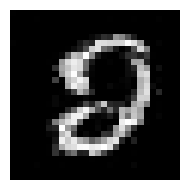

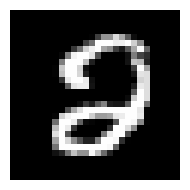

In [33]:


# 画图
print(y1)
# 展示 x_hat 中的所有图片
fig, axes = plt.subplots(1, x_hat.shape[0], figsize=(x_hat.shape[0] * 2, 2))
if x_hat.shape[0] == 1:
    axes = [axes]
for i in range(x_hat.shape[0]):
    img = x_hat[i].squeeze().detach().cpu().numpy()
    axes[i].imshow(img, cmap='gray', vmin=-1, vmax=1)  # type: ignore
    axes[i].axis('off')  # type: ignore
plt.tight_layout()
plt.show()

x_star1 = x_star[N:N + 1]
fig, axes = plt.subplots(1, x_star1.shape[0], figsize=(x_star1.shape[0] * 2, 2))
if x_star1.shape[0] == 1:
    axes = [axes]
for i in range(x_star1.shape[0]):
    img = x_star1.squeeze().detach().cpu().numpy()
    axes[i].imshow(img, cmap='gray', vmin=-1, vmax=1)  # type: ignore
    axes[i].axis('off')  # type: ignore

plt.tight_layout()
plt.show()

## 检查模型

In [ ]:
# now we can also evaluate the model by turning it into a classifier with Bayes rule, p(y|x) = p(y)p(x|y)/p(x)
data = tv.datasets.MNIST('.', transform=transform, train=False, download=False)
data_loader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True, drop_last=False)
num_correct = 0
num_examples = 0
for x, y in data_loader:  # x.shape = (B, C, W, W), y.shape = (B)

    x: torch.Tensor = x.to(device)
    y: torch.Tensor = y.to(device)
    eps = noise_std * torch.randn_like(x)

    x = x.repeat(num_classes, 1, 1, 1)  # (num_classes * B, C, W, W)
    y_ = torch.arange(num_classes, device=device).view(-1, 1).repeat(1, y.size(0)).flatten()
    # arange  -> (n)
    # view    -> (n,1)
    # repeat  -> (n,B)
    # flatten -> (n*B)

    with torch.no_grad():
        z, logdets, d = model(x, y_)
        losses = 0.5 * z.pow(2).mean(dim=[1, 2]) - logdets  # keep the batch dimension
        pred = losses.reshape(num_classes, y.size(0)).argmin(dim=0)

    num_correct += (pred == y).sum()
    num_examples += y.size(0)

print(f'Accuracy %{100 * num_correct / num_examples:.2f}')
torch.cuda.empty_cache()

In [ ]:
# 1.用一个小批量计算 IGN,CRN
# 2.